In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

PROJECT_ROOT = Path.cwd().parents[1]

DATA_ROOT = PROJECT_ROOT / "data"
PROCESSED_ROOT = DATA_ROOT / "processed"
SPLITS_ROOT = DATA_ROOT / "splits"
RESULTS_ROOT = DATA_ROOT / "results"
CHECKPOINT_ROOT = DATA_ROOT / "checkpoints"

CRIC_CROPS = PROCESSED_ROOT / "cric_crops"
CRIC_MANIFEST = PROCESSED_ROOT / "cric_learning_units.csv"
CRIC_SPLITS = SPLITS_ROOT / "cric_splits.csv"

PHASE13_RESULTS = RESULTS_ROOT / "phase13"
PHASE13_CHECKPOINTS = CHECKPOINT_ROOT / "phase13"

PHASE13_RESULTS.mkdir(parents=True, exist_ok=True)
PHASE13_CHECKPOINTS.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
BACKBONE = "densenet121"
NUM_CLASSES = 2

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8

LABEL_FRACTION = 0.05

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PHASE 13 — PSEUDO-LABELING — CRIC")
print("=" * 50)
print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )

print("Backbone:", BACKBONE)
print("Label fraction:", LABEL_FRACTION)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Maximum epochs:", EPOCHS)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)
print("Random seed:", RANDOM_SEED)

print("\n=== SETUP COMPLETE ===")

PHASE 13 — PSEUDO-LABELING — CRIC
Project root: c:\Users\nanda\Documents\cervical-semi-sl
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU memory: 6.0 GB
Backbone: densenet121
Label fraction: 0.05
Batch size: 32
Learning rate: 0.0001
Weight decay: 1e-05
Maximum epochs: 50
Early stopping patience: 8
Random seed: 42

=== SETUP COMPLETE ===


In [2]:
cric_manifest = pd.read_csv(CRIC_MANIFEST)
cric_splits = pd.read_csv(CRIC_SPLITS)

print("CRIC manifest shape:", cric_manifest.shape)
print("CRIC split shape:", cric_splits.shape)

print("\nSplit counts:")
print(cric_splits["split"].value_counts())

print("\nSplit × binary label:")
print(
    pd.crosstab(
        cric_splits["split"],
        cric_splits["binary_label"]
    )
)

print("\nColumns:")
print(cric_splits.columns.tolist())

print("\nExample crop:")
example_crop = PROJECT_ROOT / cric_splits.iloc[0]["crop_path"]
print(example_crop)
print("Exists:", example_crop.exists())

CRIC manifest shape: (11534, 9)
CRIC split shape: (11534, 10)

Split counts:
split
train    8274
test     1721
val      1539
Name: count, dtype: int64

Split × binary label:
binary_label     0     1
split                   
test          1108   613
train         4736  3538
val            935   604

Columns:
['dataset', 'image_filename', 'cell_id', 'x_pixel', 'y_pixel', 'class_bethesda', 'binary_label', 'crop_path', 'crop_valid', 'split']

Example crop:
c:\Users\nanda\Documents\cervical-semi-sl\data\processed\cric_crops\9ae8a4edde40219bad6303cebc672ee4_cell_1.png
Exists: True


In [3]:
train_df = cric_splits[
    cric_splits["split"] == "train"
].copy()

val_df = cric_splits[
    cric_splits["split"] == "val"
].copy()

test_df = cric_splits[
    cric_splits["split"] == "test"
].copy()

# Reproduce the deterministic 5% labeled subset
rng = np.random.default_rng(RANDOM_SEED)

labeled_indices = (
    train_df
    .sample(
        frac=LABEL_FRACTION,
        random_state=RANDOM_SEED
    )
    .index
)

labeled_df = train_df.loc[labeled_indices].copy()

unlabeled_df = train_df.drop(
    labeled_indices
).copy()

print("CRIC 5% PSEUDO-LABELING POOLS")
print("=" * 50)

print("Full training pool:", len(train_df))
print("Labeled pool:", len(labeled_df))
print("Unlabeled pool:", len(unlabeled_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nLabeled class distribution:")
print(
    labeled_df["binary_label"]
    .value_counts()
    .sort_index()
)

print("\nUnlabeled class distribution:")
print(
    unlabeled_df["binary_label"]
    .value_counts()
    .sort_index()
)

print("\nPool check:")
print(
    "Labeled + Unlabeled =",
    len(labeled_df) + len(unlabeled_df)
)

print(
    "Matches training pool:",
    len(labeled_df) + len(unlabeled_df) == len(train_df)
)

CRIC 5% PSEUDO-LABELING POOLS
Full training pool: 8274
Labeled pool: 414
Unlabeled pool: 7860
Validation: 1539
Test: 1721

Labeled class distribution:
binary_label
0    249
1    165
Name: count, dtype: int64

Unlabeled class distribution:
binary_label
0    4487
1    3373
Name: count, dtype: int64

Pool check:
Labeled + Unlabeled = 8274
Matches training pool: True


In [4]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cervical_ssl.datasets import CervicalDataset, create_dataloader
from src.cervical_ssl.transforms import (
    get_train_transform,
    get_val_transform,
)

train_transform = get_train_transform(BACKBONE)
val_transform = get_val_transform(BACKBONE)

labeled_dataset = CervicalDataset(
    labeled_df,
    transform=train_transform,
    project_root=PROJECT_ROOT,
)

unlabeled_dataset = CervicalDataset(
    unlabeled_df,
    transform=train_transform,
    project_root=PROJECT_ROOT,
)

val_dataset = CervicalDataset(
    val_df,
    transform=val_transform,
    project_root=PROJECT_ROOT,
)

test_dataset = CervicalDataset(
    test_df,
    transform=val_transform,
    project_root=PROJECT_ROOT,
)

labeled_loader = create_dataloader(
    labeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

unlabeled_loader = create_dataloader(
    unlabeled_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

val_loader = create_dataloader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = create_dataloader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("DATASET / DATALOADER SETUP")
print("=" * 50)
print("Labeled dataset:", len(labeled_dataset))
print("Unlabeled dataset:", len(unlabeled_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

print("\nNumber of batches:")
print("Labeled:", len(labeled_loader))
print("Unlabeled:", len(unlabeled_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))

images, labels = next(iter(labeled_loader))

print("\nLabeled batch:")
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Labels:", labels.tolist())

DATASET / DATALOADER SETUP
Labeled dataset: 414
Unlabeled dataset: 7860
Validation dataset: 1539
Test dataset: 1721

Number of batches:
Labeled: 13
Unlabeled: 246
Validation: 49
Test: 54

Labeled batch:
Image shape: torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])
Labels: [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0]


In [5]:
from src.cervical_ssl.models import create_model

model = create_model(
    backbone=BACKBONE,
    num_classes=NUM_CLASSES,
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("MODEL SETUP")
print("=" * 50)
print("Backbone:", BACKBONE)
print("Number of classes:", NUM_CLASSES)
print("Device:", DEVICE)
print("Loss:", type(criterion).__name__)
print("Optimizer:", type(optimizer).__name__)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)

MODEL SETUP
Backbone: densenet121
Number of classes: 2
Device: cuda
Loss: CrossEntropyLoss
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 1e-05
Total parameters: 6955906
Trainable parameters: 6955906


In [7]:
import inspect
from src.cervical_ssl.training import train_model

print(inspect.signature(train_model))

(model, train_loader, val_loader, criterion, optimizer, device, epochs, checkpoint_path=None, early_stopping_patience=None, selection_metric='macro_f1')


In [8]:
from src.cervical_ssl.training import train_model

warmup_history = train_model(
    model=model,
    train_loader=labeled_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    selection_metric="macro_f1",
    checkpoint_path=(
        PHASE13_CHECKPOINTS
        / "cric_pseudolabel_5pct_warmup"
        / "best_model.pt"
    ),
)

print("\n=== SUPERVISED WARM-UP COMPLETE ===")

Epoch 1/50 | Train Loss: 0.6005 | Train Acc: 0.6498 | Val Loss: 0.4202 | Val Acc: 0.8174 | Val Macro-F1: 0.7977 | Val Sensitivity: 0.6440 | Val Specificity: 0.9294
  → Best checkpoint saved (epoch 1, macro_f1=0.7977)
Epoch 2/50 | Train Loss: 0.2243 | Train Acc: 0.9348 | Val Loss: 0.3564 | Val Acc: 0.8512 | Val Macro-F1: 0.8415 | Val Sensitivity: 0.7699 | Val Specificity: 0.9037
  → Best checkpoint saved (epoch 2, macro_f1=0.8415)
Epoch 3/50 | Train Loss: 0.1419 | Train Acc: 0.9686 | Val Loss: 0.3171 | Val Acc: 0.8655 | Val Macro-F1: 0.8566 | Val Sensitivity: 0.7848 | Val Specificity: 0.9176
  → Best checkpoint saved (epoch 3, macro_f1=0.8566)
Epoch 4/50 | Train Loss: 0.0571 | Train Acc: 0.9976 | Val Loss: 0.3071 | Val Acc: 0.8655 | Val Macro-F1: 0.8600 | Val Sensitivity: 0.8510 | Val Specificity: 0.8749
  → Best checkpoint saved (epoch 4, macro_f1=0.8600)
Epoch 5/50 | Train Loss: 0.0399 | Train Acc: 0.9976 | Val Loss: 0.2942 | Val Acc: 0.8739 | Val Macro-F1: 0.8686 | Val Sensitivity: 0

In [10]:
import inspect
from src.cervical_ssl.checkpoints import load_checkpoint

print(inspect.signature(load_checkpoint))

(model, optimizer, path, scheduler=None, device='cpu')


In [12]:
warmup_checkpoint = (
    PHASE13_CHECKPOINTS
    / "cric_pseudolabel_5pct_warmup"
    / "best_model.pt"
)

print("Warm-up checkpoint:", warmup_checkpoint)
print("Exists:", warmup_checkpoint.exists())

checkpoint = torch.load(
    warmup_checkpoint,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)
model.eval()

print("\nBest warm-up model loaded successfully.")
print("Checkpoint epoch:", checkpoint["epoch"])
print(
    "Checkpoint validation Macro-F1:",
    checkpoint["val_metrics"]["macro_f1"]
    if "val_metrics" in checkpoint
    else "stored in checkpoint"
)

Warm-up checkpoint: c:\Users\nanda\Documents\cervical-semi-sl\data\checkpoints\phase13\cric_pseudolabel_5pct_warmup\best_model.pt
Exists: True

Best warm-up model loaded successfully.
Checkpoint epoch: 22
Checkpoint validation Macro-F1: stored in checkpoint


In [13]:
all_pseudo_labels = []

model.eval()

with torch.no_grad():
    for batch_images, _ in unlabeled_loader:
        batch_images = batch_images.to(DEVICE)

        logits = model(batch_images)
        probabilities = torch.softmax(logits, dim=1)

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

        for prediction, conf in zip(
            predictions.cpu().numpy(),
            confidence.cpu().numpy()
        ):
            all_pseudo_labels.append(
                {
                    "pseudo_label": int(prediction),
                    "confidence": float(conf),
                }
            )

pseudo_df = unlabeled_df.reset_index(drop=True).copy()

pseudo_predictions_df = pd.DataFrame(
    all_pseudo_labels
)

pseudo_df = pd.concat(
    [
        pseudo_df,
        pseudo_predictions_df
    ],
    axis=1
)

print("PSEUDO-LABEL GENERATION")
print("=" * 50)

print("Unlabeled samples:", len(unlabeled_df))
print("Generated predictions:", len(pseudo_df))

print("\nPseudo-label distribution:")
print(
    pseudo_df["pseudo_label"]
    .value_counts()
    .sort_index()
)

print("\nConfidence statistics:")
print(
    pseudo_df["confidence"].describe()
)

print("\nFirst 10 pseudo-labels:")
print(
    pseudo_df[
        [
            "crop_path",
            "pseudo_label",
            "confidence"
        ]
    ].head(10)
)

PSEUDO-LABEL GENERATION
Unlabeled samples: 7860
Generated predictions: 7860

Pseudo-label distribution:
pseudo_label
0    4433
1    3427
Name: count, dtype: int64

Confidence statistics:
count    7860.000000
mean        0.941630
std         0.111276
min         0.500135
25%         0.951616
50%         0.995138
75%         0.999167
max         0.999996
Name: confidence, dtype: float64

First 10 pseudo-labels:
                                           crop_path  pseudo_label  confidence
0  data\processed\cric_crops\9ae8a4edde40219bad63...             1    0.999877
1  data\processed\cric_crops\9ae8a4edde40219bad63...             1    0.583883
2  data\processed\cric_crops\9ae8a4edde40219bad63...             1    0.618027
3  data\processed\cric_crops\9ae8a4edde40219bad63...             1    0.984692
4  data\processed\cric_crops\9ae8a4edde40219bad63...             0    0.919127
5  data\processed\cric_crops\9ae8a4edde40219bad63...             0    0.998962
6  data\processed\cric_crops\9ae8a

In [14]:
thresholds = [0.80, 0.90, 0.95, 0.975, 0.99, 0.995]

threshold_summary = []

for threshold in thresholds:
    selected = pseudo_df[
        pseudo_df["confidence"] >= threshold
    ]

    threshold_summary.append(
        {
            "threshold": threshold,
            "selected_samples": len(selected),
            "retention_percent": (
                len(selected) / len(pseudo_df) * 100
            ),
            "pseudo_normal": (
                selected["pseudo_label"] == 0
            ).sum(),
            "pseudo_abnormal": (
                selected["pseudo_label"] == 1
            ).sum(),
        }
    )

threshold_df = pd.DataFrame(threshold_summary)

print("PSEUDO-LABEL CONFIDENCE THRESHOLD SENSITIVITY")
print("=" * 70)
print(threshold_df.to_string(index=False))

PSEUDO-LABEL CONFIDENCE THRESHOLD SENSITIVITY
 threshold  selected_samples  retention_percent  pseudo_normal  pseudo_abnormal
     0.800              6956          88.498728           3969             2987
     0.900              6438          81.908397           3707             2731
     0.950              5923          75.356234           3458             2465
     0.975              5369          68.307888           3155             2214
     0.990              4596          58.473282           2734             1862
     0.995              3951          50.267176           2354             1597


In [15]:
PSEUDO_LABEL_THRESHOLD = 0.95

confident_pseudo_df = pseudo_df[
    pseudo_df["confidence"] >= PSEUDO_LABEL_THRESHOLD
].copy()

confident_pseudo_df["binary_label"] = (
    confident_pseudo_df["pseudo_label"]
)

print("CONFIDENT PSEUDO-LABEL POOL")
print("=" * 50)

print("Confidence threshold:", PSEUDO_LABEL_THRESHOLD)
print("Original unlabeled samples:", len(pseudo_df))
print("Confident pseudo-labeled samples:", len(confident_pseudo_df))
print(
    "Rejected low-confidence samples:",
    len(pseudo_df) - len(confident_pseudo_df)
)

print("\nPseudo-label distribution:")
print(
    confident_pseudo_df["binary_label"]
    .value_counts()
    .sort_index()
)

print("\nConfidence statistics:")
print(
    confident_pseudo_df["confidence"].describe()
)

CONFIDENT PSEUDO-LABEL POOL
Confidence threshold: 0.95
Original unlabeled samples: 7860
Confident pseudo-labeled samples: 5923
Rejected low-confidence samples: 1937

Pseudo-label distribution:
binary_label
0    3458
1    2465
Name: count, dtype: int64

Confidence statistics:
count    5923.000000
mean        0.992851
std         0.010998
min         0.950039
25%         0.991538
50%         0.998026
75%         0.999480
max         0.999996
Name: confidence, dtype: float64


In [16]:
# Mark the source of each training sample
labeled_train_df = labeled_df.copy()
labeled_train_df["label_source"] = "ground_truth"
labeled_train_df["pseudo_confidence"] = 1.0

pseudo_train_df = confident_pseudo_df.copy()
pseudo_train_df["label_source"] = "pseudo"
pseudo_train_df["pseudo_confidence"] = pseudo_train_df["confidence"]

# Keep only the columns needed by the dataset, plus tracking information
semi_sl_train_df = pd.concat(
    [
        labeled_train_df,
        pseudo_train_df
    ],
    ignore_index=True
)

# Shuffle deterministically
semi_sl_train_df = (
    semi_sl_train_df
    .sample(
        frac=1.0,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

print("SEMI-SL TRAINING POOL")
print("=" * 50)

print("Ground-truth labeled samples:", len(labeled_train_df))
print("Pseudo-labeled samples:", len(pseudo_train_df))
print("Total training samples:", len(semi_sl_train_df))

print("\nLabel source:")
print(
    semi_sl_train_df["label_source"]
    .value_counts()
)

print("\nBinary label distribution:")
print(
    semi_sl_train_df["binary_label"]
    .value_counts()
    .sort_index()
)

print("\nLabel source × binary label:")
print(
    pd.crosstab(
        semi_sl_train_df["label_source"],
        semi_sl_train_df["binary_label"]
    )
)

print("\nTraining pool check:")
print(
    "414 + 5923 =",
    len(labeled_train_df) + len(pseudo_train_df)
)
print(
    "Matches combined pool:",
    len(semi_sl_train_df) == 414 + 5923
)

SEMI-SL TRAINING POOL
Ground-truth labeled samples: 414
Pseudo-labeled samples: 5923
Total training samples: 6337

Label source:
label_source
pseudo          5923
ground_truth     414
Name: count, dtype: int64

Binary label distribution:
binary_label
0    3707
1    2630
Name: count, dtype: int64

Label source × binary label:
binary_label     0     1
label_source            
ground_truth   249   165
pseudo        3458  2465

Training pool check:
414 + 5923 = 6337
Matches combined pool: True


In [17]:
semi_sl_train_dataset = CervicalDataset(
    semi_sl_train_df,
    transform=train_transform,
    project_root=PROJECT_ROOT,
)

semi_sl_train_loader = create_dataloader(
    semi_sl_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

print("SEMI-SL TRAINING DATALOADER")
print("=" * 50)

print("Training samples:", len(semi_sl_train_dataset))
print("Training batches:", len(semi_sl_train_loader))

images, labels = next(iter(semi_sl_train_loader))

print("\nFirst batch:")
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Unique labels:", torch.unique(labels).tolist())
print("Batch size:", len(labels))

SEMI-SL TRAINING DATALOADER
Training samples: 6337
Training batches: 199

First batch:
Image shape: torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])
Unique labels: [0, 1]
Batch size: 32


In [18]:
semi_sl_model = create_model(
    backbone=BACKBONE,
    num_classes=NUM_CLASSES,
).to(DEVICE)

semi_sl_criterion = nn.CrossEntropyLoss()

semi_sl_optimizer = torch.optim.AdamW(
    semi_sl_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("SEMI-SL MODEL")
print("=" * 50)
print("Backbone:", BACKBONE)
print("Device:", DEVICE)
print("Loss:", type(semi_sl_criterion).__name__)
print("Optimizer:", type(semi_sl_optimizer).__name__)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

trainable_parameters = sum(
    parameter.numel()
    for parameter in semi_sl_model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", trainable_parameters)

SEMI-SL MODEL
Backbone: densenet121
Device: cuda
Loss: CrossEntropyLoss
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 1e-05
Trainable parameters: 6955906


In [19]:
unlabeled_inference_dataset = CervicalDataset(
    unlabeled_df,
    transform=val_transform,
    project_root=PROJECT_ROOT,
)

unlabeled_inference_loader = create_dataloader(
    unlabeled_inference_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("DETERMINISTIC PSEUDO-LABEL INFERENCE")
print("=" * 50)
print("Unlabeled samples:", len(unlabeled_inference_dataset))
print("Inference batches:", len(unlabeled_inference_loader))

images, labels = next(iter(unlabeled_inference_loader))

print("\nFirst batch:")
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Unique placeholder labels:", torch.unique(labels).tolist())

DETERMINISTIC PSEUDO-LABEL INFERENCE
Unlabeled samples: 7860
Inference batches: 246

First batch:
Image shape: torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])
Unique placeholder labels: [0, 1]


In [20]:
all_pseudo_labels = []

# Use the best supervised warm-up model
model.eval()

with torch.no_grad():
    for batch_images, _ in unlabeled_inference_loader:
        batch_images = batch_images.to(DEVICE)

        logits = model(batch_images)
        probabilities = torch.softmax(logits, dim=1)

        confidence, predictions = torch.max(
            probabilities,
            dim=1
        )

        for prediction, conf in zip(
            predictions.cpu().numpy(),
            confidence.cpu().numpy()
        ):
            all_pseudo_labels.append(
                {
                    "pseudo_label": int(prediction),
                    "confidence": float(conf),
                }
            )

pseudo_df = unlabeled_df.reset_index(drop=True).copy()

pseudo_predictions_df = pd.DataFrame(
    all_pseudo_labels
)

pseudo_df = pd.concat(
    [
        pseudo_df,
        pseudo_predictions_df
    ],
    axis=1
)

print("DETERMINISTIC PSEUDO-LABEL GENERATION")
print("=" * 50)

print("Unlabeled samples:", len(unlabeled_df))
print("Generated predictions:", len(pseudo_df))

print("\nPseudo-label distribution:")
print(
    pseudo_df["pseudo_label"]
    .value_counts()
    .sort_index()
)

print("\nConfidence statistics:")
print(
    pseudo_df["confidence"].describe()
)

DETERMINISTIC PSEUDO-LABEL GENERATION
Unlabeled samples: 7860
Generated predictions: 7860

Pseudo-label distribution:
pseudo_label
0    4420
1    3440
Name: count, dtype: int64

Confidence statistics:
count    7860.000000
mean        0.942626
std         0.109418
min         0.500215
25%         0.951665
50%         0.995122
75%         0.999159
max         0.999998
Name: confidence, dtype: float64


In [21]:
PSEUDO_LABEL_THRESHOLD = 0.95

confident_pseudo_df = pseudo_df[
    pseudo_df["confidence"] >= PSEUDO_LABEL_THRESHOLD
].copy()

confident_pseudo_df["binary_label"] = (
    confident_pseudo_df["pseudo_label"]
)

print("CONFIDENT PSEUDO-LABEL SELECTION")
print("=" * 50)

print("Threshold:", PSEUDO_LABEL_THRESHOLD)
print("Original unlabeled samples:", len(pseudo_df))
print("Confident pseudo-labeled samples:", len(confident_pseudo_df))
print("Rejected samples:", len(pseudo_df) - len(confident_pseudo_df))

print("\nPseudo-label distribution:")
print(
    confident_pseudo_df["binary_label"]
    .value_counts()
    .sort_index()
)

print("\nConfidence statistics:")
print(
    confident_pseudo_df["confidence"].describe()
)

CONFIDENT PSEUDO-LABEL SELECTION
Threshold: 0.95
Original unlabeled samples: 7860
Confident pseudo-labeled samples: 5918
Rejected samples: 1942

Pseudo-label distribution:
binary_label
0    3454
1    2464
Name: count, dtype: int64

Confidence statistics:
count    5918.000000
mean        0.992972
std         0.010752
min         0.950039
25%         0.991730
50%         0.998008
75%         0.999476
max         0.999998
Name: confidence, dtype: float64


In [22]:
labeled_train_df = labeled_df.copy()

labeled_train_df["label_source"] = "ground_truth"
labeled_train_df["pseudo_confidence"] = 1.0

pseudo_train_df = confident_pseudo_df.copy()

pseudo_train_df["label_source"] = "pseudo"
pseudo_train_df["pseudo_confidence"] = (
    pseudo_train_df["confidence"]
)

semi_sl_train_df = pd.concat(
    [
        labeled_train_df,
        pseudo_train_df
    ],
    ignore_index=True
)

semi_sl_train_df = (
    semi_sl_train_df
    .sample(
        frac=1.0,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

print("FINAL SEMI-SL TRAINING POOL")
print("=" * 50)

print("Ground-truth samples:", len(labeled_train_df))
print("Pseudo-labeled samples:", len(pseudo_train_df))
print("Total training samples:", len(semi_sl_train_df))

print("\nLabel source:")
print(
    semi_sl_train_df["label_source"]
    .value_counts()
)

print("\nBinary label distribution:")
print(
    semi_sl_train_df["binary_label"]
    .value_counts()
    .sort_index()
)

print("\nSource × label:")
print(
    pd.crosstab(
        semi_sl_train_df["label_source"],
        semi_sl_train_df["binary_label"]
    )
)

print(
    "\nPool size check:",
    len(semi_sl_train_df) == (
        len(labeled_train_df) +
        len(pseudo_train_df)
    )
)

FINAL SEMI-SL TRAINING POOL
Ground-truth samples: 414
Pseudo-labeled samples: 5918
Total training samples: 6332

Label source:
label_source
pseudo          5918
ground_truth     414
Name: count, dtype: int64

Binary label distribution:
binary_label
0    3703
1    2629
Name: count, dtype: int64

Source × label:
binary_label     0     1
label_source            
ground_truth   249   165
pseudo        3454  2464

Pool size check: True


In [23]:
semi_sl_train_dataset = CervicalDataset(
    semi_sl_train_df,
    transform=train_transform,
    project_root=PROJECT_ROOT,
)

semi_sl_train_loader = create_dataloader(
    semi_sl_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

print("FINAL SEMI-SL TRAINING DATALOADER")
print("=" * 50)

print("Training samples:", len(semi_sl_train_dataset))
print("Training batches:", len(semi_sl_train_loader))

images, labels = next(iter(semi_sl_train_loader))

print("\nFirst batch:")
print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Unique labels:", torch.unique(labels).tolist())
print("Batch size:", len(labels))

FINAL SEMI-SL TRAINING DATALOADER
Training samples: 6332
Training batches: 198

First batch:
Image shape: torch.Size([32, 3, 128, 128])
Label shape: torch.Size([32])
Unique labels: [0, 1]
Batch size: 32


In [24]:
semi_sl_checkpoint = (
    PHASE13_CHECKPOINTS
    / "cric_pseudolabel_5pct"
    / "best_model.pt"
)

semi_sl_history = train_model(
    model=semi_sl_model,
    train_loader=semi_sl_train_loader,
    val_loader=val_loader,
    criterion=semi_sl_criterion,
    optimizer=semi_sl_optimizer,
    device=DEVICE,
    epochs=EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    selection_metric="macro_f1",
    checkpoint_path=semi_sl_checkpoint,
)

print("\n=== SEMI-SL TRAINING COMPLETE ===")
print("Checkpoint:", semi_sl_checkpoint)

Epoch 1/50 | Train Loss: 0.1059 | Train Acc: 0.9627 | Val Loss: 0.2712 | Val Acc: 0.9149 | Val Macro-F1: 0.9119 | Val Sensitivity: 0.9305 | Val Specificity: 0.9048
  → Best checkpoint saved (epoch 1, macro_f1=0.9119)
Epoch 2/50 | Train Loss: 0.0347 | Train Acc: 0.9889 | Val Loss: 0.3666 | Val Acc: 0.8902 | Val Macro-F1: 0.8857 | Val Sensitivity: 0.8825 | Val Specificity: 0.8952
Epoch 3/50 | Train Loss: 0.0219 | Train Acc: 0.9926 | Val Loss: 0.3714 | Val Acc: 0.8980 | Val Macro-F1: 0.8934 | Val Sensitivity: 0.8808 | Val Specificity: 0.9091
Epoch 4/50 | Train Loss: 0.0190 | Train Acc: 0.9931 | Val Loss: 0.3901 | Val Acc: 0.8993 | Val Macro-F1: 0.8965 | Val Sensitivity: 0.9354 | Val Specificity: 0.8759
Epoch 5/50 | Train Loss: 0.0114 | Train Acc: 0.9962 | Val Loss: 0.3595 | Val Acc: 0.8999 | Val Macro-F1: 0.8963 | Val Sensitivity: 0.9089 | Val Specificity: 0.8941
Epoch 6/50 | Train Loss: 0.0108 | Train Acc: 0.9959 | Val Loss: 0.4435 | Val Acc: 0.8934 | Val Macro-F1: 0.8899 | Val Sensitivi

In [25]:
semi_sl_checkpoint = (
    PHASE13_CHECKPOINTS
    / "cric_pseudolabel_5pct"
    / "best_model.pt"
)

print("Semi-SL checkpoint:", semi_sl_checkpoint)
print("Exists:", semi_sl_checkpoint.exists())

checkpoint = torch.load(
    semi_sl_checkpoint,
    map_location=DEVICE,
    weights_only=False,
)

semi_sl_model.load_state_dict(
    checkpoint["model_state_dict"]
)

semi_sl_model.to(DEVICE)
semi_sl_model.eval()

print("\nBest Semi-SL checkpoint loaded successfully.")
print("Best epoch:", checkpoint["epoch"])

if "val_metrics" in checkpoint:
    print(
        "Stored validation Macro-F1:",
        checkpoint["val_metrics"]["macro_f1"]
    )
else:
    print(
        "Stored validation Macro-F1: "
        "see training log — 0.9119"
    )

Semi-SL checkpoint: c:\Users\nanda\Documents\cervical-semi-sl\data\checkpoints\phase13\cric_pseudolabel_5pct\best_model.pt
Exists: True

Best Semi-SL checkpoint loaded successfully.
Best epoch: 1
Stored validation Macro-F1: see training log — 0.9119


In [27]:
from src.cervical_ssl.evaluation import evaluate_model

semi_sl_test_metrics = evaluate_model(
    model=semi_sl_model,
    dataloader=test_loader,
    device=DEVICE,
)

print("CRIC 5% PSEUDO-LABELING — TEST RESULTS")
print("=" * 50)

for metric_name, value in semi_sl_test_metrics.items():
    print(f"{metric_name}: {value:.4f}")

CRIC 5% PSEUDO-LABELING — TEST RESULTS
accuracy: 0.8466
precision: 0.7374
recall: 0.8842
specificity: 0.8258
macro_f1: 0.8390
auroc: 0.9302


In [28]:
from src.cervical_ssl.evaluation import evaluate_model

semi_sl_test_metrics = evaluate_model(
    model=semi_sl_model,
    dataloader=test_loader,
    device=DEVICE,
)

print("CRIC 5% PSEUDO-LABELING — TEST RESULTS")
print("=" * 50)

for metric_name, value in semi_sl_test_metrics.items():
    print(f"{metric_name}: {value:.4f}")

CRIC 5% PSEUDO-LABELING — TEST RESULTS
accuracy: 0.8466
precision: 0.7374
recall: 0.8842
specificity: 0.8258
macro_f1: 0.8390
auroc: 0.9302


In [30]:
supervised_5pct_metrics = {
    "accuracy": 0.8332,
    "precision": 0.7547,
    "recall": 0.7879,
    "specificity": 0.8583,
    "macro_f1": 0.8199,
    "auroc": 0.9072,
}

comparison_rows = []

for metric in supervised_5pct_metrics:
    supervised_value = supervised_5pct_metrics[metric]
    semi_sl_value = semi_sl_test_metrics[metric]

    comparison_rows.append(
        {
            "metric": (
                "sensitivity"
                if metric == "recall"
                else metric
            ),
            "supervised_5pct": supervised_value,
            "pseudo_labeling_5pct": semi_sl_value,
            "difference": semi_sl_value - supervised_value,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)

print("CRIC 5% — SUPERVISED vs PSEUDO-LABELING")
print("=" * 70)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

CRIC 5% — SUPERVISED vs PSEUDO-LABELING
     metric  supervised_5pct  pseudo_labeling_5pct  difference
   accuracy           0.8332                0.8466      0.0134
  precision           0.7547                0.7374     -0.0173
sensitivity           0.7879                0.8842      0.0963
specificity           0.8583                0.8258     -0.0325
   macro_f1           0.8199                0.8390      0.0191
      auroc           0.9072                0.9302      0.0230


In [31]:
experiment_id = "cric_pseudolabel_5pct_densenet121_seed42"

experiment_results_dir = (
    PHASE13_RESULTS / experiment_id
)

experiment_results_dir.mkdir(
    parents=True,
    exist_ok=True
)

result_record = {
    "experiment_id": experiment_id,
    "dataset": "CRIC",
    "method": "pseudo_labeling",
    "label_fraction": LABEL_FRACTION,
    "backbone": BACKBONE,
    "seed": RANDOM_SEED,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "pseudo_label_threshold": PSEUDO_LABEL_THRESHOLD,
    "total_training_samples": len(semi_sl_train_df),
    "ground_truth_samples": len(labeled_train_df),
    "unlabeled_samples": len(unlabeled_df),
    "accepted_pseudo_labels": len(confident_pseudo_df),
    "rejected_unlabeled_samples": (
        len(unlabeled_df) - len(confident_pseudo_df)
    ),
    "best_epoch": int(checkpoint["epoch"]),
    "best_val_macro_f1": 0.9119,
    "test_metrics": {
        metric: float(value)
        for metric, value in semi_sl_test_metrics.items()
    },
}

result_path = (
    experiment_results_dir / "metrics.json"
)

with open(result_path, "w") as f:
    json.dump(
        result_record,
        f,
        indent=4
    )

comparison_path = (
    experiment_results_dir / "supervised_vs_pseudolabeling.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("OFFICIAL RESULTS SAVED")
print("=" * 50)
print("Metrics:", result_path)
print("Comparison:", comparison_path)
print("Metrics file exists:", result_path.exists())
print("Comparison file exists:", comparison_path.exists())

OFFICIAL RESULTS SAVED
Metrics: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\metrics.json
Comparison: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\supervised_vs_pseudolabeling.csv
Metrics file exists: True
Comparison file exists: True


In [32]:
pseudo_statistics = {
    "experiment_id": experiment_id,
    "dataset": "CRIC",
    "label_fraction": LABEL_FRACTION,
    "random_seed": RANDOM_SEED,
    "unlabeled_samples": len(unlabeled_df),
    "threshold": PSEUDO_LABEL_THRESHOLD,
    "accepted_samples": len(confident_pseudo_df),
    "rejected_samples": (
        len(unlabeled_df) - len(confident_pseudo_df)
    ),
    "pseudo_label_distribution": {
        str(int(label)): int(count)
        for label, count in (
            confident_pseudo_df["binary_label"]
            .value_counts()
            .sort_index()
            .items()
        )
    },
    "confidence_mean": float(
        confident_pseudo_df["confidence"].mean()
    ),
    "confidence_std": float(
        confident_pseudo_df["confidence"].std()
    ),
    "confidence_min": float(
        confident_pseudo_df["confidence"].min()
    ),
    "confidence_median": float(
        confident_pseudo_df["confidence"].median()
    ),
    "confidence_max": float(
        confident_pseudo_df["confidence"].max()
    ),
}

pseudo_stats_path = (
    experiment_results_dir / "pseudo_label_statistics.json"
)

with open(pseudo_stats_path, "w") as f:
    json.dump(
        pseudo_statistics,
        f,
        indent=4
    )

print("Pseudo-label statistics saved:")
print(pseudo_stats_path)

Pseudo-label statistics saved:
c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\pseudo_label_statistics.json


History shape: (9, 10)
History columns:
['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'val_macro_f1', 'val_sensitivity', 'val_specificity', 'train_time', 'val_time']


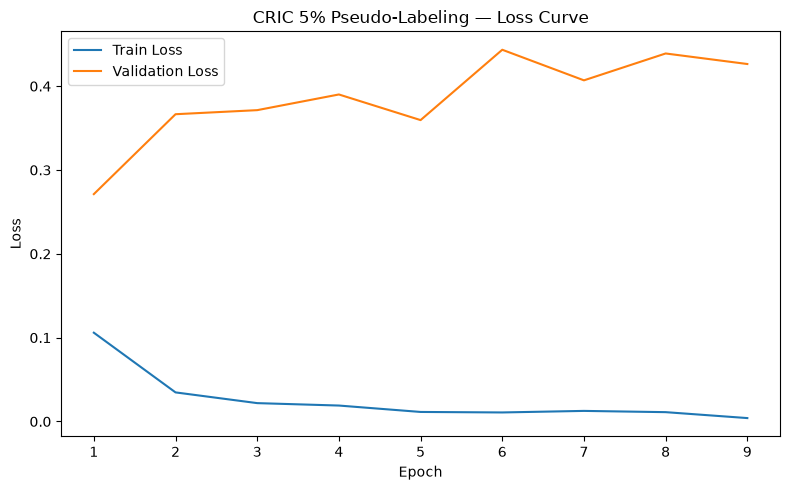

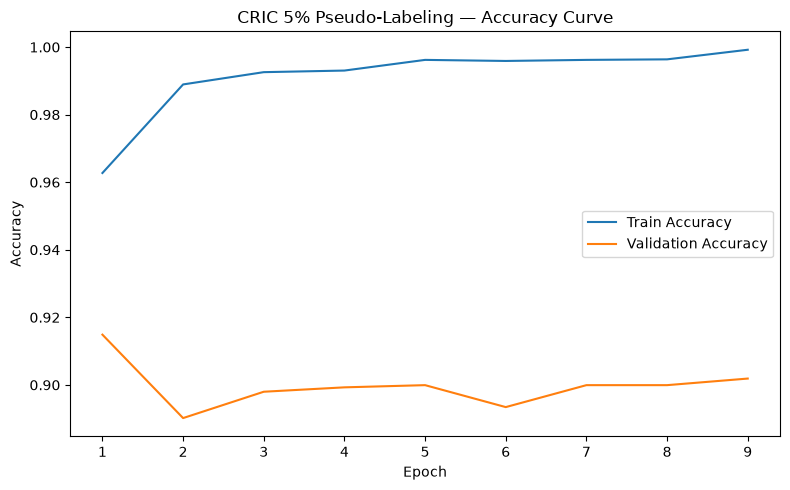

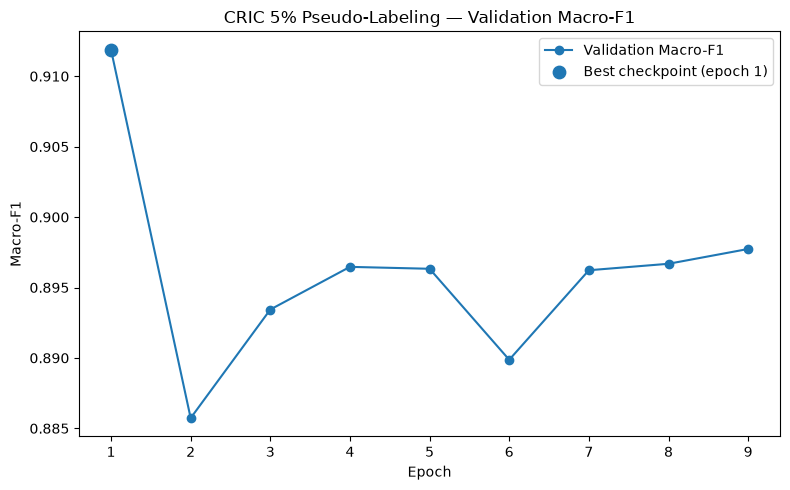

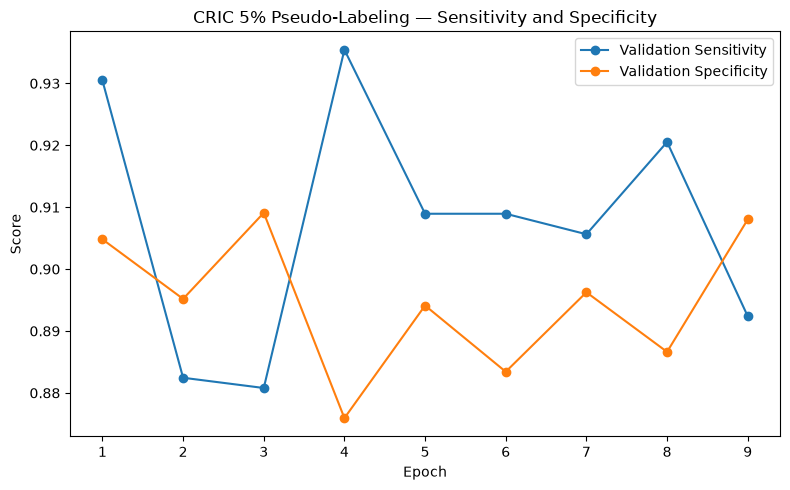


=== PHASE 13 CRIC ARTIFACTS SAVED ===
Epochs recorded: 9
Best epoch: 1
Best validation Macro-F1: 0.9118789788733164

Saved artifacts:
experiment_id: cric_pseudolabel_5pct_densenet121_seed42
metrics: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\metrics.json
comparison: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\supervised_vs_pseudolabeling.csv
pseudo_label_statistics: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\pseudo_label_statistics.json
training_history_csv: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\training_history.csv
training_history_json: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_pseudolabel_5pct_densenet121_seed42\training_history.json
loss_curve: c:\Users\nanda\Documents\cervical-semi-sl\data\results\phase13\cric_

In [38]:
import matplotlib.pyplot as plt

curves_dir = experiment_results_dir / "curves"
curves_dir.mkdir(
    parents=True,
    exist_ok=True
)

# --------------------------------------------------
# 1. Convert training history to DataFrame
# --------------------------------------------------

history_df = pd.DataFrame(
    semi_sl_history["history"]
)

print("History shape:", history_df.shape)
print("History columns:")
print(list(history_df.columns))

# --------------------------------------------------
# 2. Save complete epoch-by-epoch history
# --------------------------------------------------

history_path = (
    experiment_results_dir / "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

history_json_path = (
    experiment_results_dir / "training_history.json"
)

with open(history_json_path, "w") as f:
    json.dump(
        semi_sl_history,
        f,
        indent=4,
        default=float
    )

# --------------------------------------------------
# 3. Loss curve
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CRIC 5% Pseudo-Labeling — Loss Curve")
plt.legend()
plt.tight_layout()

loss_path = curves_dir / "loss_curve.png"

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# --------------------------------------------------
# 4. Accuracy curve
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CRIC 5% Pseudo-Labeling — Accuracy Curve")
plt.legend()
plt.tight_layout()

accuracy_path = curves_dir / "accuracy_curve.png"

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# --------------------------------------------------
# 5. Validation Macro-F1 curve
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1"
)

best_epoch = int(
    semi_sl_history["best_epoch"]
)

best_f1 = float(
    semi_sl_history["best_metric"]
)

plt.scatter(
    [best_epoch],
    [best_f1],
    s=80,
    label=f"Best checkpoint (epoch {best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("CRIC 5% Pseudo-Labeling — Validation Macro-F1")
plt.legend()
plt.tight_layout()

f1_path = curves_dir / "macro_f1_curve.png"

plt.savefig(
    f1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# --------------------------------------------------
# 6. Validation Sensitivity / Specificity curve
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["val_sensitivity"],
    marker="o",
    label="Validation Sensitivity"
)

plt.plot(
    history_df["epoch"],
    history_df["val_specificity"],
    marker="o",
    label="Validation Specificity"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("CRIC 5% Pseudo-Labeling — Sensitivity and Specificity")
plt.legend()
plt.tight_layout()

sens_spec_path = (
    curves_dir / "sensitivity_specificity_curve.png"
)

plt.savefig(
    sens_spec_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# --------------------------------------------------
# 7. Save artifact summary
# --------------------------------------------------

artifact_summary = {
    "experiment_id": experiment_id,
    "metrics": str(result_path),
    "comparison": str(comparison_path),
    "pseudo_label_statistics": str(pseudo_stats_path),
    "training_history_csv": str(history_path),
    "training_history_json": str(history_json_path),
    "loss_curve": str(loss_path),
    "accuracy_curve": str(accuracy_path),
    "macro_f1_curve": str(f1_path),
    "sensitivity_specificity_curve": str(sens_spec_path),
    "checkpoint": str(semi_sl_checkpoint),
}

artifact_summary_path = (
    experiment_results_dir / "artifact_summary.json"
)

with open(artifact_summary_path, "w") as f:
    json.dump(
        artifact_summary,
        f,
        indent=4
    )

print("\n=== PHASE 13 CRIC ARTIFACTS SAVED ===")
print("=" * 50)

print("Epochs recorded:", len(history_df))
print("Best epoch:", best_epoch)
print("Best validation Macro-F1:", best_f1)

print("\nSaved artifacts:")
for name, path in artifact_summary.items():
    print(f"{name}: {path}")